# <img style="float: left; padding-right: 20px; width: 200px" src="https://raw.githubusercontent.com/raxlab/imt2200-data/main/media/logo.jpg">  IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

# <h1><center>Tarea 03: Exploración de datos </center></h1>

**Fecha de Entrega:** 28 de octubre de 2025, a las 23:59.

**Fecha de publicación**: 14 de octubre de 2025.

**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 03 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tarea.

- Deben hacer sus consultas y comentarios sobre la Tarea a través del canal de Tareas en el Foro del curso en Canvas.

---

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

En esta tarea vamos a analizar la distribución de vulneribilidad escolar para distintos establecimientos educacionales en Chile, desde enseñanza parvularia hasta enseñanza media. Específicamente, queremos entender cómo se comporta un índice de vulnerabilidad en relación a variables como ruralidad, tipo de dependencia y comuna del establecimiento.

---

## 2. Datos

En este estudio, trabajaremos con los resultados publicados anualmente sobre por la JUNAEB
sobre vulnerabilidad de establecimientos educacionales en todo el territorio nacional. Estos resultados están disponibles en la siguiente página web:

* Índices de Vulnerabilidad (JUNAEB): https://www.junaeb.cl/medicion-la-vulnerabilidad-ivm/

Adicionalmente, para visualizar las variables, utilizaremos los mapas vectoriales que disponibiliza la Biblioteca del Congreso Nacional (BCN):

* Mapoteca BCN: https://www.bcn.cl/siit/mapas_vectoriales/index_html

### 2.1 Descarga de datos y conceptos generales (1 punto)

Acceda a los links entregados y descargue el set de datos del **Índice de Vulnerabilidad Multidimensional de Establecimientos Educacionales** para el año 2025. Este debería ser un documento XLSX con múltiples pestañas, incluyendo entre estas un índice que describe las columnas presentes en la base de datos.
Descargue además los archivos correspondientes a la **División comunal: polígonos de las comunas de Chile**. Este se descarga en formato `.zip` y contiene archivos shapefile para visualizar las comunas del país.

Investigue sobre este índice y responda de manera concisa: 
* ¿En qué consiste el IVM? ¿Qué rango de valores toma y qué significan? 
* ¿Cómo se obtiene el IVM de un establecimiento educacional?



Respuesta:

1. ¿En qué consiste el IVM? ¿Qué rango de valores toma y qué significan? 

El IVM es una medida elaborada por la JUNAEB que estima el nivel de vulnerabilidad socioeconomica de los estudiantes en un establecimiento educacional.
Se basa en multiples dimensiones como la situacion economica y laboral del hogar, condiciones del entorno (acceso a servicios, vivienda, etc.) y, la salud y educación de los estudiantes.

El IVM toma valores entre 0 y 1. 0 significa baja vulnerabilidad, 1 significa alta vulnerabilidad. Un valor cercano a 0,75 o mas indica establecimientos con alta concentración de estudiantes vulnerables.


2. ¿Cómo se obtiene el IVM de un establecimiento educacional?

El calculo se realiza usando información proveniente de diversas fuentes administrativas ccomo JUNAEB, MINEDUC, Registro Social de Hogares, entre otras.

Su proceso es:
- Identificar a los estudiantes matriculados en cada establecimiento.
- Se le asigna a cada estudiante un índice individual de vulnerabilidad basado en su hogar.
- Por ultimo, se promedian esos dos valores dentro del establecimiento, entonces ese promedio es el IVM del establecimiento.

## 3. Lectura y limpieza de datos (1 punto)

### 3.1 Datos de establecimientos (0.5 puntos)
El ruta descargado contiene información sobre establecimientos de cuatro tipos: Parvularia, Primer Ciclo Básica, Segundo Ciclo Básica y Media.
Cargue los datos de los establecimientos en cuatro DataFrames distintos.

Revise cada uno de sus sets de datos y haga un proceso de limpieza si lo considera necesario (manejo de valores nulos, duplicados, inválidos, transformación de tipos de datos, etc). De haberlos, identifique qué atributos son categóricos y transforme los tipos de columna de acuerdo a su decisión, mostrando todos los posibles valores de cada categoría.

Justifique **todas** sus decisiones, **incluso** si decide no realizar una limpieza o transformación.

Finalmente, responda:

* a. ¿Cuántos establecimientos tiene cada set de datos?
* b. ¿Cuánto espacio en memoria ocupan en total los 4 datasets?
* c. ¿Cuántos estudiantes fueron evaluados en todo el país para cada nivel de enseñanza para el año 2025?


In [1]:
import pandas as pd
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np



In [2]:
ruta = "data/IVM_Establecimientos_2025-2.xlsx"
excel = pd.ExcelFile(ruta)

df_parv = pd.read_excel(ruta, sheet_name="Parvularia")  #Leemos los archivos excel
df_ciclo1 = pd.read_excel(ruta, sheet_name="1º Ciclo Básico")
df_ciclo2 = pd.read_excel(ruta, sheet_name="2º Ciclo Básico")
df_media = pd.read_excel(ruta, sheet_name="Media")

In [3]:
df_parv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6163 entries, 0 to 6162
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID_RBD                    6163 non-null   int64  
 1   DV_RBD                    6163 non-null   int64  
 2   DS_NOM_ESTABLE            6163 non-null   object 
 3   DS_TIPO_DEPENDENCIA       6163 non-null   object 
 4   DS_RURALIDAD              6163 non-null   object 
 5   ID_REGION_ESTABLE         6163 non-null   int64  
 6   ID_PROVINCIA_ESTABLE      6163 non-null   int64  
 7   ID_COMUNA_ESTABLE         6163 non-null   int64  
 8   DS_COMUNA_ESTABLE         6163 non-null   object 
 9   N EVALUADO                6163 non-null   int64  
 10  IVM Establecimiento       6163 non-null   float64
 11  IVM Bajo                  6163 non-null   int64  
 12  IVM Medio                 6163 non-null   int64  
 13  IVM Alto                  6163 non-null   int64  
 14  IVM Muy 

In [4]:
df_ciclo1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7082 entries, 0 to 7081
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID_RBD                7082 non-null   int64  
 1   DV_RBD                7082 non-null   int64  
 2   DS_NOM_ESTABLE        7082 non-null   object 
 3   DS_TIPO_DEPENDENCIA   7082 non-null   object 
 4   DS_RURALIDAD          7082 non-null   object 
 5   ID_REGION_ESTABLE     7082 non-null   int64  
 6   ID_PROVINCIA_ESTABLE  7082 non-null   int64  
 7   ID_COMUNA_ESTABLE     7082 non-null   int64  
 8   DS_COMUNA_ESTABLE     7082 non-null   object 
 9   N EVALUADO            7082 non-null   int64  
 10  IVM Establecimiento   7082 non-null   float64
 11  IVM Bajo              7082 non-null   int64  
 12  IVM Medio             7082 non-null   int64  
 13  IVM Alto              7082 non-null   int64  
 14  IVM Muy Alto          7082 non-null   int64  
 15  IVM Salud            

In [5]:
df_ciclo2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5662 entries, 0 to 5661
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID_RBD                5662 non-null   int64  
 1   DV_RBD                5662 non-null   int64  
 2   DS_NOM_ESTABLE        5662 non-null   object 
 3   DS_TIPO_DEPENDENCIA   5662 non-null   object 
 4   DS_RURALIDAD          5662 non-null   object 
 5   ID_REGION_ESTABLE     5662 non-null   int64  
 6   ID_PROVINCIA_ESTABLE  5662 non-null   int64  
 7   ID_COMUNA_ESTABLE     5662 non-null   int64  
 8   DS_COMUNA_ESTABLE     5662 non-null   object 
 9   N EVALUADO            5662 non-null   int64  
 10  IVM Establecimiento   5662 non-null   float64
 11  IVM Bajo              5662 non-null   int64  
 12  IVM Medio             5662 non-null   int64  
 13  IVM Alto              5662 non-null   int64  
 14  IVM Muy Alto          5662 non-null   int64  
dtypes: float64(1), int64(

In [6]:
df_media.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2618 entries, 0 to 2617
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID_RBD                2618 non-null   int64  
 1   DV_RBD                2618 non-null   int64  
 2   DS_NOM_ESTABLE        2618 non-null   object 
 3   DS_TIPO_DEPENDENCIA   2618 non-null   object 
 4   DS_RURALIDAD          2618 non-null   object 
 5   ID_REGION_ESTABLE     2618 non-null   int64  
 6   ID_PROVINCIA_ESTABLE  2618 non-null   int64  
 7   ID_COMUNA_ESTABLE     2618 non-null   int64  
 8   DS_COMUNA_ESTABLE     2618 non-null   object 
 9   N EVALUADO            2618 non-null   int64  
 10  IVM Establecimiento   2618 non-null   float64
 11  IVM Bajo              2618 non-null   int64  
 12  IVM Medio             2618 non-null   int64  
 13  IVM Alto              2618 non-null   int64  
 14  IVM Muy Alto          2618 non-null   int64  
dtypes: float64(1), int64(

No hay valores nulos en ningun df

In [7]:
df_parv.duplicated().sum()

np.int64(0)

In [8]:
df_ciclo1.duplicated().sum()

np.int64(0)

In [9]:
df_ciclo2.duplicated().sum()

np.int64(0)

In [10]:
df_media.duplicated().sum()

np.int64(0)

ningun valor duplicado

**a. ¿Cuántos establecimientos tiene cada set de datos?**

- df_parv : 6163 establecimientos
- df_ciclo1 : 7082 establecimientos
- df_ciclo2 : 5662 establecimientos
- df_media : 2618 establecimientos


**b. ¿Cuánto espacio en memoria ocupan en total los 4 datasets?**

- df_parv : 1011.2+ KB
- df_ciclo1 : 1.2+ MB
- df_ciclo2 : 663.6+ KB
- df_media : 306.9+ KB

- Total : **3181.7 KB ≈ 3.1 MB**

**c. ¿Cuántos estudiantes fueron evaluados en todo el país para cada nivel de enseñanza para el año 2025?**

In [11]:
total_evaluados = df_media['N EVALUADO'].sum()
print(f"Total de estudiantes evaluados: {total_evaluados}")

Total de estudiantes evaluados: 901899


### 3.2 Datos geográficos (0.5 puntos)

Cargue en un GeoDataFrame de GeoPandas la información de los polígonos de cada comuna del país.

Como realizamos en la Tarea pasada, puede transformar el Coordinate Reference System (CRS) a EPSG 4326, para tener la información de los puntos de los polígonos con latitud y longitud.

obtenemos la ruta 

In [12]:
comunas_path = Path("data/Comunas/comunas.shp")     #Obtenemos la ruta de las comunas

Cargamos el shapefile

In [13]:
gdf = gpd.read_file(comunas_path)   #Leemos el archivo
print("CRS original:", gdf.crs)

CRS original: EPSG:3857


Lo pasamos aa EPSG 4326

In [14]:
gdf_4326 = gdf.to_crs(epsg=4326)

In [15]:
print("CRS destino:", gdf_4326.crs)

CRS destino: EPSG:4326


## 4. Análisis descriptivo (1.5 puntos)

En esta sección haremos una exploración preliminar de los 4 sets de datos cargados. Para cada una de las siguientes preguntas, sustente su respuesta con al menos un gráfico y su análisis respectivo.

**Recomendación:** puede utilizar el método `subplots()` de `matplotlib.pyplot` para facilitar la visualización de múltiples gráficos a la vez.

### 4.1 Ruralidad (0.8 pts)
* a. ¿Cuál es la cantidad de establecimientos rurales vs urbanos según nivel de enseñanza?
* b. ¿Cómo se distribuye el IVM según nivel de enseñanza y ruralidad?


**Respuesta y comentarios:**

a. Obtenemos la suma total de Urbano y Rural de cada nivel de enseñanza

In [16]:
urbano_parv = (df_parv['DS_RURALIDAD'] == 'Urbano').sum()   #Calculamos la Suma total de establecimientos urbanos de parvulo
rural_parv = (df_parv['DS_RURALIDAD'] == 'Rural').sum()     #Calculamos la Suma total de establecimientos rurales de parvulo

print("Total urbano:", urbano_parv)
print("Total rural:", rural_parv)

Total urbano: 4903
Total rural: 1260


In [17]:
urbano_ciclo1 = (df_ciclo1['DS_RURALIDAD'] == 'Urbano').sum()   #Calculamos la Suma total de establecimientos urbanos de ciclo1
rural_ciclo1 = (df_ciclo1['DS_RURALIDAD'] == 'Rural').sum()     #Calculamos la Suma total de establecimientos rurales de ciclo1

print("Total urbano:", urbano_ciclo1)
print("Total rural:", rural_ciclo1)

Total urbano: 4128
Total rural: 2954


In [18]:
urbano_ciclo2 = (df_ciclo2['DS_RURALIDAD'] == 'Urbano').sum()   #Calculamos la Suma total de establecimientos urbanos de ciclo2
rural_ciclo2 = (df_ciclo2['DS_RURALIDAD'] == 'Rural').sum()     #Calculamos la Suma total de establecimientos rurales de ciclo2

print("Total urbano:", urbano_ciclo2)
print("Total rural:", rural_ciclo2)

Total urbano: 4170
Total rural: 1492


In [19]:
urbano_media = (df_media['DS_RURALIDAD'] == 'Urbano').sum()     #Calculamos la Suma total de establecimientos urbanos de media
rural_media = (df_media['DS_RURALIDAD'] == 'Rural').sum()       #Calculamos la Suma total de establecimientos rurales de media

print("Total urbano:", urbano_media)
print("Total rural:", rural_media)

Total urbano: 2449
Total rural: 169


In [20]:
data = {
    'Nivel': ['Parvularia', 'Ciclo 1', 'Ciclo 2', 'Media'],  # Creamos el Dataframe con la suma
    'Urbano': [urbano_parv, urbano_ciclo1, urbano_ciclo2, urbano_media],
    'Rural': [rural_parv, rural_ciclo1, rural_ciclo2, rural_media]
}

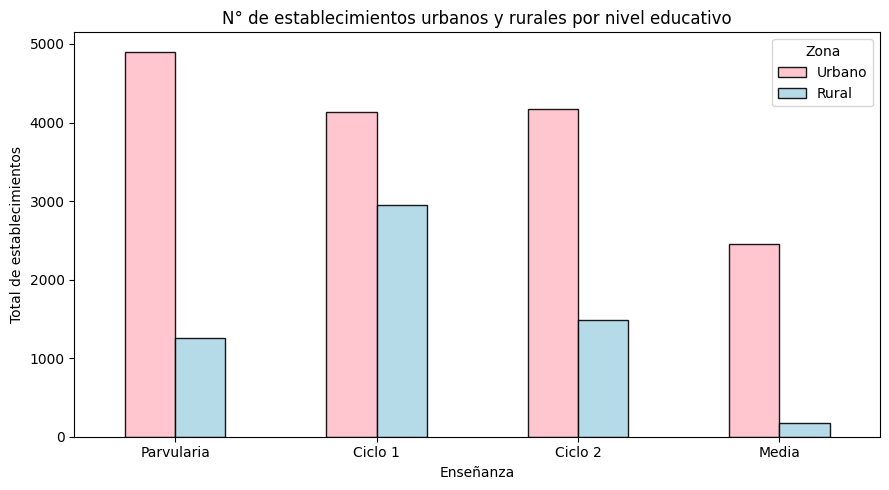

In [21]:
df_ruralidad = pd.DataFrame(data)
df_ruralidad.set_index('Nivel', inplace=True)


colores = {
    'Urbano': 'pink',
    'Rural': 'lightblue'    
}


ax = df_ruralidad.plot(
    kind='bar',
    figsize=(9,5),
    color=[colores[c] for c in df_ruralidad.columns],
    edgecolor='black',
    alpha=0.9
)


plt.title('N° de establecimientos urbanos y rurales por nivel educativo')
plt.xlabel('Enseñanza')
plt.ylabel('Total de establecimientos')
plt.xticks(rotation=0)
plt.legend(title='Zona')
plt.tight_layout()
plt.show()

**b. ¿Cómo se distribuye el IVM según nivel de enseñanza y ruralidad?**

In [22]:
promedios_parv= df_parv.groupby('DS_RURALIDAD')['IVM Establecimiento'].mean()   # Sacamos el promedio de establecimientos rurales y urbanos de parvulo
promedios_parv

DS_RURALIDAD
Rural     61.068737
Urbano    54.019154
Name: IVM Establecimiento, dtype: float64

In [23]:
promedios_ciclo1 = df_ciclo1.groupby('DS_RURALIDAD')['IVM Establecimiento'].mean()  # Sacamos el promedio de establecimientos rurales y urbanos de ciclo1
promedios_ciclo1

DS_RURALIDAD
Rural     43.400184
Urbano    43.609622
Name: IVM Establecimiento, dtype: float64

In [24]:
promedios_ciclo2 = df_ciclo2.groupby('DS_RURALIDAD')['IVM Establecimiento'].mean()  # Sacamos el promedio de establecimientos rurales y urbanos de ciclo2
promedios_ciclo2

DS_RURALIDAD
Rural     36.866174
Urbano    38.993564
Name: IVM Establecimiento, dtype: float64

In [25]:
promedios_media = df_media.groupby('DS_RURALIDAD')['IVM Establecimiento'].mean()    # Sacamos el promedio de establecimientos rurales y urbanos de media
promedios_media

DS_RURALIDAD
Rural     19.672758
Urbano    20.292701
Name: IVM Establecimiento, dtype: float64

In [26]:
establecimientos_ivm = {    # Juntamos las columnas para verlo de mejor manera
    'Nivel': ['Parvularia', 'Ciclo 1', 'Ciclo 2', 'Media'],
    'Rural': [
        promedios_parv['Rural'],
        promedios_ciclo1['Rural'],
        promedios_ciclo2['Rural'],
        promedios_media['Rural']
    ],
    'Urbano': [
        promedios_parv['Urbano'],
        promedios_ciclo1['Urbano'],
        promedios_ciclo2['Urbano'],
        promedios_media['Urbano']
    ]
}

df_ivm = pd.DataFrame(establecimientos_ivm)
df_ivm.set_index('Nivel', inplace=True)
print(df_ivm)

                Rural     Urbano
Nivel                           
Parvularia  61.068737  54.019154
Ciclo 1     43.400184  43.609622
Ciclo 2     36.866174  38.993564
Media       19.672758  20.292701


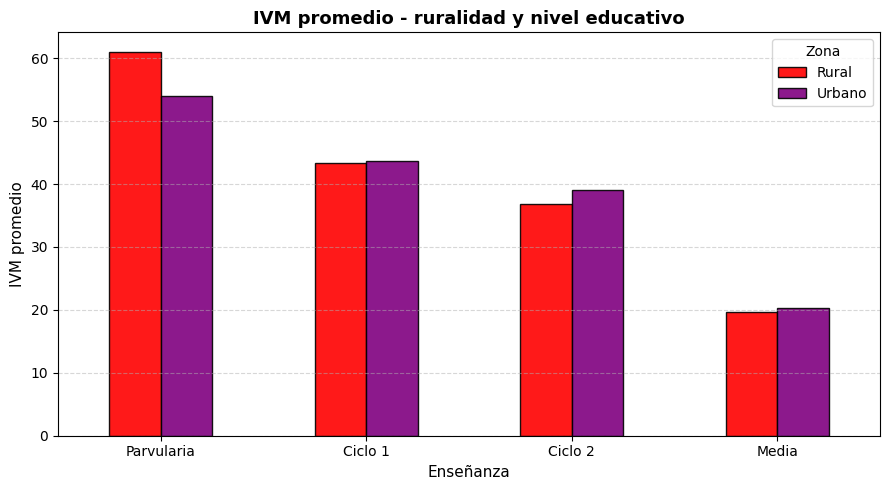

In [27]:
colores = {
    'Rural': 'red',
    'Urbano': 'purple'
}


ax = df_ivm.plot(
    kind='bar',
    figsize=(9,5),
    color=[colores[c] for c in df_ivm.columns],
    edgecolor='black',
    alpha=0.9
)


plt.title('IVM promedio - ruralidad y nivel educativo', fontsize=13, weight='bold')
plt.xlabel('Enseñanza', fontsize=11)
plt.ylabel('IVM promedio', fontsize=11)
plt.xticks(rotation=0)
plt.legend(title='Zona')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


- Parvularia presenta los IVM mas altos, especialmente en zonas rurales.
- En el Ciclo 1 y Ciclo 2, la diferencia entre rural y urbano es minima, aunque los rurales suelen mantener un IVM un poco mayor.
- En Media, los valores son los mas bajos, la diferencia entre rural y urbano es minima.


Las zonas rurales presentan, mayor vulnerabilidad en todos los niveles de educación, pero la diferencia con las zonas urbanas disminuye cuando aumenta el nivel educativo.

### 4.2 Tipo de establecimiento (0.7 pts)

* ¿Cómo es la distribución del IVM promedio de los establecimientos según tipo de dependencia y nivel de enseñanza? 

In [28]:
promedio_dep_parv = df_parv.groupby(['DS_TIPO_DEPENDENCIA'])['IVM Establecimiento'].mean() # Calculamos el promedio de dependencia  de parvulo
promedio_dep_parv

DS_TIPO_DEPENDENCIA
Corporación Municipal               54.412060
Municipal DAEM                      59.037537
Particular Subvencionado            53.565329
Servicio Local de Educación(SLE)    57.197915
Name: IVM Establecimiento, dtype: float64

In [29]:
promedio_dep_ciclo1 = df_ciclo1.groupby(['DS_TIPO_DEPENDENCIA'])['IVM Establecimiento'].mean() # Calculamos el promedio de dependencia del ciclo1
promedio_dep_ciclo1

DS_TIPO_DEPENDENCIA
Administración Delegada (C. P. 3166)    40.222215
Corporación Municipal                   45.013497
Municipal DAEM                          43.656486
Particular Subvencionado                42.723499
Servicio Local de Educación(SLE)        44.706152
Name: IVM Establecimiento, dtype: float64

In [30]:
promedio_dep_ciclo2 = df_ciclo2.groupby(['DS_TIPO_DEPENDENCIA'])['IVM Establecimiento'].mean()  # Calculamos el promedio de dependencia del ciclo2
promedio_dep_ciclo2

DS_TIPO_DEPENDENCIA
Administración Delegada (C. P. 3166)    40.522709
Corporación Municipal                   39.868568
Municipal DAEM                          37.870933
Particular Subvencionado                38.498390
Servicio Local de Educación(SLE)        38.605706
Name: IVM Establecimiento, dtype: float64

In [31]:
promedio_dep_media = df_media.groupby(['DS_TIPO_DEPENDENCIA'])['IVM Establecimiento'].mean()    # Calculamos el promedio de dependencia de media
promedio_dep_media

DS_TIPO_DEPENDENCIA
Administración Delegada (C. P. 3166)    23.869148
Corporación Municipal                   23.679409
Municipal DAEM                          20.901203
Particular Subvencionado                19.159692
Servicio Local de Educación(SLE)        22.867277
Name: IVM Establecimiento, dtype: float64

In [32]:
df_dependencia_edu = pd.DataFrame({ #Creamos un df con el promedio de dependencia de cada nivel de educación
    'Parvularia': promedio_dep_parv,
    'Ciclo 1': promedio_dep_ciclo1,
    'Ciclo 2': promedio_dep_ciclo2,
    'Media': promedio_dep_media
})

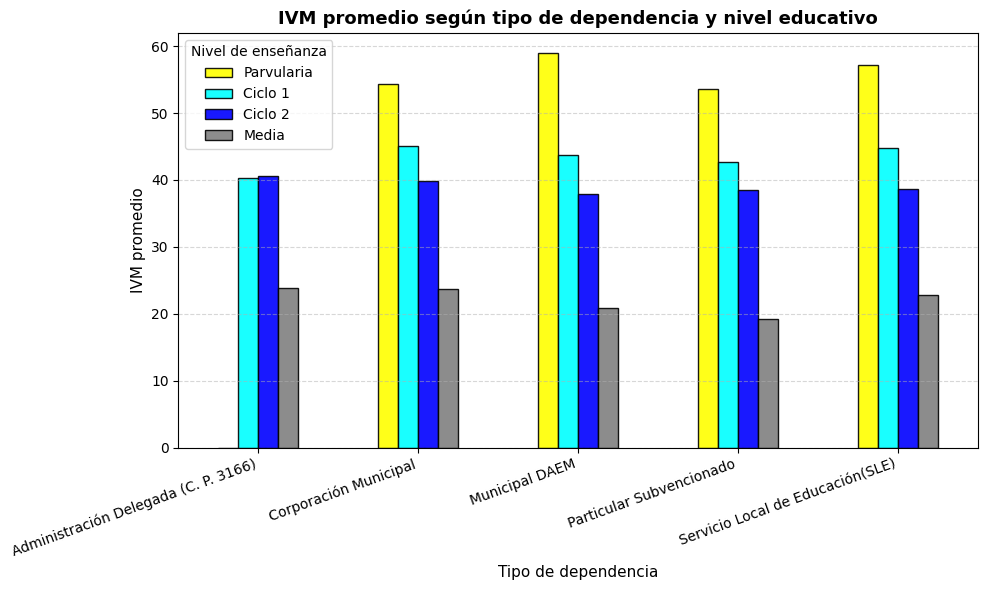

In [33]:
colores = ["yellow", "aqua", "blue", "gray"]

ax = df_dependencia_edu.plot(
    kind='bar',
    figsize=(10,6),
    color=colores,
    edgecolor='black',
    alpha=0.9
)

plt.title('IVM promedio según tipo de dependencia y nivel educativo', fontsize=13, weight='bold')
plt.xlabel('Tipo de dependencia', fontsize=11)
plt.ylabel('IVM promedio', fontsize=11)
plt.xticks(rotation=20, ha='right')
plt.legend(title='Nivel de enseñanza')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Los establecimientos municipales tienen los IVM promedio mas altos, mostrando mayor vulnerabilidad socioeconomica, por otro lado estan los particulares subvencionados y pagados muestran valores mas bajos.
Ademas, el IVM disminuye a medida que aumenta el nivel educativo.

### 4.3 Pregunta Bono: Dimensiones de vulnerabilidad (1 punto)

Para los niveles de enseñanza Parvularia y Básica Primer ciclo (1-4º), tenemos información sobre distintas dimensiones de que se utilizan para calcular el IVM, como condición socioeconómica familiar y comunal, salud, etc. 

* Para todo Chile, en promedio, ¿cuál es la dimensión con mayor puntaje de IVM para cada uno de estos dos niveles de enseñanza?

In [34]:
columnas_parv = [   #definimos una lista con los nombres de las columnas
    'IVM Salud',
    'IVM CSE Familiar',
    'IVM Estimulación y Apoyo',
    'IVM Familia',
    'IVM CSE Comunal',
    'IVM Derechos'
]

columnas_ciclo1 = [
    'IVM Salud',
    'IVM Discapacidad',
    'IVM Educación',
    'IVM Habitabilidad',
    'IVM Familiar',
    'IVM Participación',
    'IVM CSE Familia',
    'IVM CSE Comunal'
]

In [35]:
prom_parv = df_parv[columnas_parv].mean().sort_values(ascending=False)  # Calculamos el promedio IVM
prom_ciclo1 = df_ciclo1[columnas_ciclo1].mean().sort_values(ascending=False)

In [36]:
print("Promedios Parvularia:\n", prom_parv, "\n")

Promedios Parvularia:
 IVM Familia                 70.667085
IVM CSE Familiar            43.194210
IVM Estimulación y Apoyo    43.095565
IVM Salud                   27.910199
IVM CSE Comunal             18.127686
IVM Derechos                14.211290
dtype: float64 



El mas alto es **IVM Familia**

In [37]:
print("Promedios Ciclo1:\n", prom_ciclo1, "\n")

Promedios Ciclo1:
 IVM CSE Familia      54.390762
IVM Salud            43.102350
IVM Familiar         32.196868
IVM CSE Comunal      22.728506
IVM Habitabilidad    20.741263
IVM Educación        13.038839
IVM Discapacidad      5.924766
IVM Participación     5.326800
dtype: float64 



El mas alto es **IVM CSE Familia**

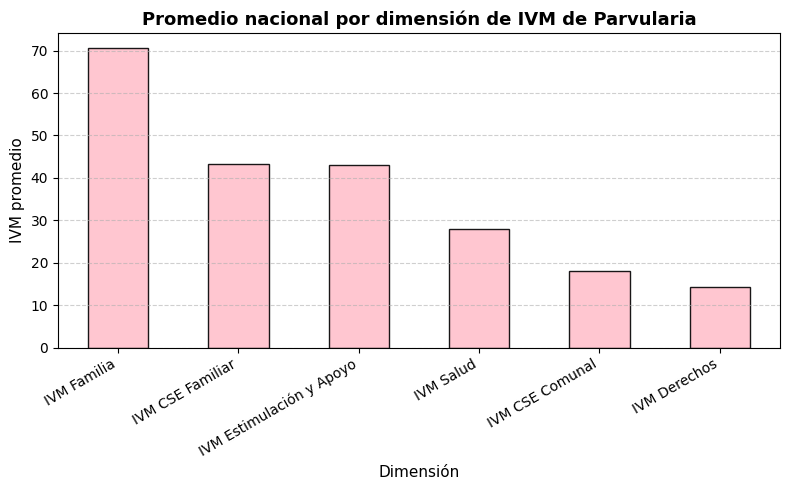

In [38]:
plt.figure(figsize=(8,5))
prom_parv.plot(kind='bar', color='pink', edgecolor='black', alpha=0.9)

plt.title('Promedio nacional por dimensión de IVM de Parvularia', fontsize=13, weight='bold')
plt.xlabel('Dimensión', fontsize=11)
plt.ylabel('IVM promedio', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

La dimensión con mayor puntaje IVM para la enseñanza Parvularia es **IVM Familia**

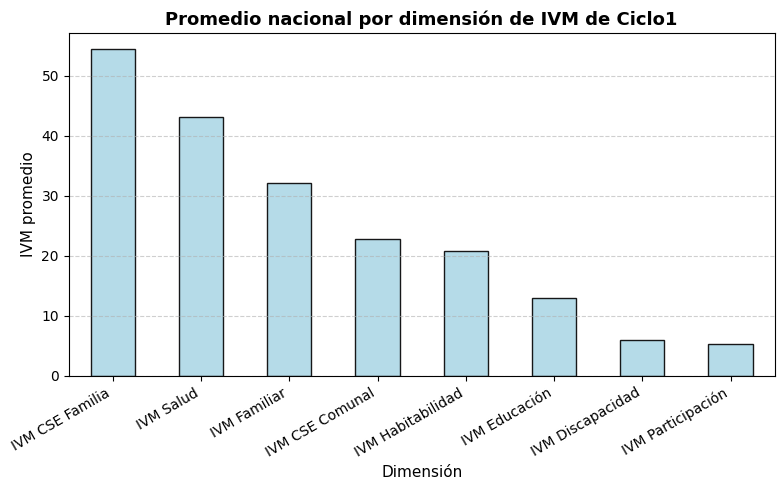

In [39]:
plt.figure(figsize=(8,5))
prom_ciclo1.plot(kind='bar', color='lightblue', edgecolor='black', alpha=0.9)

plt.title('Promedio nacional por dimensión de IVM de Ciclo1', fontsize=13, weight='bold')
plt.xlabel('Dimensión', fontsize=11)
plt.ylabel('IVM promedio', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

La dimensión con mayor puntaje IVM para la enseñanza Ciclo1 es **IVM CSE Familia**

## 5. Agrupación de bases de datos (2 puntos)

El objetivo de esta sección será agrupar los establecimientos según la comuna en la que se encuentran para obtener un resumen general sobre la vulnerabilidad escolar en cada una de ellas. Al finalizar esta sección, tendremos un nuevo DataFrame `agg_comunal` que contenga, al menos, la siguiente información:

* Comuna (nombre y ID)
* Región (ID)
* Cantidad de establecimientos rurales de la comuna
* Cantidad de establecimientos urbanos de la comuna
* Cantidad total de establecimientos de la comuna
* Porcentaje de establecimientos rurales
* IVM Promedio Parvularia de la comuna
* IVM Promedio Básica Primer Ciclo de la comuna
* IVM Promedio Básica Segundo Ciclo de la comuna
* IVM Promedio Media de la comuna
* Objeto geometry de GeoPandas correspondiente al polígono de la comuna respectiva

Armaremos este DataFrame paso a paso.

### 5.1 Cálculo de IVM promedio por comuna (0.8 pts)

Primero, para cada uno sus 4 DataFrames, calcule el promedio de la columna `IVM Establecimiento` según comuna. Almacene este valor en una nueva columna llamada `IVM Promedio {NIVEL DE ENSEÑANZA}` (por ejemplo, para enseñanza parvularia, cree la columna `IVM Promedio Parvularia`).

Junte los 4 resultados que obtuvo en un solo DataFrame `ivm_comunal` que contenga:
* Comuna (nombre y ID)
* Región (ID)
* IVM Promedio Parvularia de la comuna
* IVM Promedio Básica Primer Ciclo de la comuna
* IVM Promedio Básica Segundo Ciclo de la comuna
* IVM Promedio Media de la comuna

Ponga siempre atención al tamaño de sus DataFrames: como estamos agrupando comunalmente, estos siempre debiesen tener una cantidad de filas igual a las comunas de Chile.

In [123]:
prom_parv = (
    df_parv.groupby(["ID_REGION_ESTABLE", "ID_COMUNA_ESTABLE", "DS_COMUNA_ESTABLE"], as_index=False) #Calculamos el promedio de cada comuna y el nivel educativo
           ["IVM Establecimiento"]
           .mean() #Calcula el promedio
           .rename(columns={"IVM Establecimiento": "IVM Promedio Parvularia de la comuna"}) #renombramos 
)

prom_ciclo1 = (
    df_ciclo1.groupby(["ID_REGION_ESTABLE", "ID_COMUNA_ESTABLE", "DS_COMUNA_ESTABLE"], as_index=False)
             ["IVM Establecimiento"]
             .mean()
             .rename(columns={"IVM Establecimiento": "IVM Promedio Ciclo1 de la comuna"})
)

prom_ciclo2 = (
    df_ciclo2.groupby(["ID_REGION_ESTABLE", "ID_COMUNA_ESTABLE", "DS_COMUNA_ESTABLE"], as_index=False)
             ["IVM Establecimiento"]
             .mean()
             .rename(columns={"IVM Establecimiento": "IVM Promedio Ciclo2 de la comuna"})
)

prom_media = (
    df_media.groupby(["ID_REGION_ESTABLE", "ID_COMUNA_ESTABLE", "DS_COMUNA_ESTABLE"], as_index=False)
            ["IVM Establecimiento"]
            .mean()
            .rename(columns={"IVM Establecimiento": "IVM Promedio Media de la comuna"})
)

In [124]:
ivm_comuna = (
    prom_parv
    .merge(prom_ciclo1, on=["ID_REGION_ESTABLE", "ID_COMUNA_ESTABLE", "DS_COMUNA_ESTABLE"], how="outer") #Con .merge() unimos dfs
    .merge(prom_ciclo2, on=["ID_REGION_ESTABLE", "ID_COMUNA_ESTABLE", "DS_COMUNA_ESTABLE"], how="outer")
    .merge(prom_media,  on=["ID_REGION_ESTABLE", "ID_COMUNA_ESTABLE", "DS_COMUNA_ESTABLE"], how="outer")
)

In [ ]:
ivm_comuna["Comuna (nombre y ID)"] = (
    ivm_comuna["DS_COMUNA_ESTABLE"] + " (" + ivm_comuna["ID_COMUNA_ESTABLE"].astype(str) + ")"#Unimos el nombre de la comuna y el id correspondiente
)

In [ ]:
ivm_comunal = ivm_comuna[[  #seleccionamos las columnas a usar
    "Comuna (nombre y ID)",
    "ID_REGION_ESTABLE",
    "IVM Promedio Parvularia de la comuna",
    "IVM Promedio Ciclo1 de la comuna",
    "IVM Promedio Ciclo2 de la comuna",
    "IVM Promedio Media de la comuna"
]].rename(columns={
    "ID_REGION_ESTABLE": "Region (ID)"# renombramos
})

ivm_comunal.head()

,Comuna (nombre y ID),Region (ID),IVM Promedio Parvularia de la comuna,IVM Promedio Ciclo1 de la comuna,IVM Promedio Ciclo2 de la comuna,IVM Promedio Media de la comuna
0,Iquique (1101),1,50.882970,45.131982,39.182182,22.109517
1,Alto Hospicio (1107),1,55.419776,46.599904,41.289463,24.250219
2,Pozo Almonte (1401),1,59.804991,44.159905,35.386361,22.676408
3,Camiña (1402),1,68.812360,46.127984,34.998365,17.966318
4,Colchane (1403),1,71.742419,56.888644,32.721880,27.648785


### 5.2 Establecimientos por comuna y ruralidad (0.8 pts)

Ahora contaremos la cantidad de establecimientos por comuna según ruralidad. Como buscamos la cantidad total de establecimientos, consideramos establecimientos de todos los niveles educacionales vistos. Para esto, combine los 4 DataFrames que cargó y genere un nuevo DataFrame `estab_comunal` que contenga:

* Comuna (ID)
* Cantidad de establecimientos rurales
* Cantidad de establecimientos urbanos
* Cantidad total de establecimientos
* Porcentaje de establecimientos rurales (Establecimientos rurales / Total establecimientos * 100)

Tenga en cuenta de que pueden aparecer establecimientos duplicados al combinar estos 4 DataFrames (por ejemplo, establecimientos que imparten múltiples niveles de enseñanza, desde 1º básico hasta 4º medio). Preocúpese de manejar estos casos antes de agrupar sus datos según ruralidad.

In [42]:
df_todos = pd.concat([df_parv, df_ciclo1, df_ciclo2, df_media], ignore_index=True)  # Unimos los 4 dataframes

In [43]:
cols_necesarias = ["ID_RBD", "ID_COMUNA_ESTABLE", "DS_RURALIDAD"]   # Nos quedamos solo con lo que necesitamos

Eliminamos los establecimientos duplicados entre distintos tipos de educación

Si aparece varias veces, tomaamos la ruralidad "mas frecuente"

In [44]:

##### FUNCION HECHA CON IA ##### para manejar los casos de establecimientos repetidos
def sin_rep(s):
    m = s.mode()    # busca el valor más frecuente en la serie
    if not m.empty:
        return m.iat[0]     # si hay moda, devuelve ese valor
    s = s.dropna()      # si no hay moda, elimina nulos
    return s.iat[0] if not s.empty else None    # devuelve el primer valor disponible

In [45]:
df_no_dupli = ( #DataFrame sin establecimientos duplicados
    df_todos.groupby("ID_RBD", as_index=False)
            .agg(ID_COMUNA_ESTABLE=("ID_COMUNA_ESTABLE", "first"),
                 DS_RURALIDAD=("DS_RURALIDAD", sin_rep))
) 

In [149]:
conteo = (  
    df_no_dupli.groupby("ID_COMUNA_ESTABLE")["DS_RURALIDAD"] #Agrupamos "ID_COMUNA_ESTABLE" y "DS_RURALIDAD"vemos por comuna si es que es rural o urbano el est
             .value_counts()    # Contamos cuantos son urbanos y rurales
             .unstack(fill_value=0)     #transformamos en columnas rural y urbano
             .reset_index() #comuna queda como un indicw
)


conteo["total_establecimientos"] = conteo["Rural"] + conteo["Urbano"]
conteo["porcentaje rurales"] = (conteo["Rural"] / conteo["Urbano"] * 100).round(2)

In [ ]:
conteo["porcentaje rurales"] = conteo["porcentaje rurales"].replace([np.inf, -np.inf], np.nan) # si noy hay un porcentaje de rurales entonces lo dejamos en NaN

In [156]:
estab_comunal = conteo.rename(columns={"ID_COMUNA_ESTABLE": "COMUNA_ID", "Rural":"Cantidad establecimientos Rurales", "Urbano":"Cantidad establecimientos Urbanos"})[
    ["COMUNA_ID", "Cantidad establecimientos Rurales", "Cantidad establecimientos Urbanos", "total_establecimientos", "porcentaje rurales"]
]

estab_comunal

DS_RURALIDAD,COMUNA_ID,Cantidad establecimientos Rurales,Cantidad establecimientos Urbanos,total_establecimientos,porcentaje rurales
0,1101,3,81,84,3.70
1,1107,3,41,44,7.32
2,1401,12,0,12,NaN
3,1402,10,0,10,NaN
4,1403,4,0,4,NaN
...,...,...,...,...,...
340,16301,19,17,36,111.76
341,16302,19,7,26,271.43
342,16303,8,2,10,400.00
343,16304,5,1,6,500.00


### 5.3 Unión de bases de datos y polígonos (0.4 pts)

Finalmente, vamos a generar el DataFrame `agg_comunal` con la información de los dos previos DataFrames creados.
Combine la información de las dos secciones anteriores para crear su base de datos unificada. Por último, agregue la columna `geometry` con la información geográfica de cada comuna.

In [ ]:
agg_comunal = ivm_comunal.merge(estab_comunal, on="COMUNA_ID", how="left")  # Juntamos los dfs

In [ ]:
gdf = gpd.read_file("data/Comunas/comunas.shp") #leemos el archivo, para despues usarlo con la columna geometry

In [ ]:
for columna in ["COMUNA_ID", "ID_COMUNA_ESTABLE", "ID_COMUNA", "COD_COMUNA", "CUT_COM", "cod_comuna"]:# posibles nombres    ####LINEA HECHA CON IA####
    if columna in gdf.columns:  #Verificamos si el nombre existe
        gdf = gdf.rename(columns={columna: "COMUNA_ID"})#renombramos la columna
        break

In [ ]:
gdf["COMUNA_ID"] = gdf["COMUNA_ID"].astype(int) #Nos aseguramos que los IDs sean iguales
agg_comunal["COMUNA_ID"] = agg_comunal["COMUNA_ID"].astype(int)

agg_comunal = gdf.merge(agg_comunal, on="COMUNA_ID", how="right")#juntamos los dfs
agg_comunal = gpd.GeoDataFrame(agg_comunal, geometry="geometry", crs=gdf.crs)# lo convertimos en un Geodataframe

In [ ]:
agg_comunal = agg_comunal[[#Ordenasmos las columnas
    "Comuna (nombre y ID)",
    "Región (ID)",
    "Cantidad establecimientos Rurales",
    "Cantidad establecimientos Urbanos",
    "total_establecimientos",
    "porcentaje rurales",
    "IVM Promedio Parvularia de la comuna",
    "IVM Promedio Ciclo1 de la comuna",
    "IVM Promedio Ciclo2 de la comuna",
    "IVM Promedio Media de la comuna",
    "geometry"
]]

agg_comunal.head()

,Comuna (nombre y ID),Región (ID),Cantidad establecimientos Rurales,Cantidad establecimientos Urbanos,total_establecimientos,porcentaje rurales,IVM Promedio Parvularia de la comuna,IVM Promedio Ciclo1 de la comuna,IVM Promedio Ciclo2 de la comuna,IVM Promedio Media de la comuna,geometry
0,Iquique (1101),1,3,81,84,3.70,50.882970,45.131982,39.182182,22.109517,"MULTIPOLYGON (((-7810213.515 -2298008.28, -781..."
1,Alto Hospicio (1107),1,3,41,44,7.32,55.419776,46.599904,41.289463,24.250219,"POLYGON ((-7780326.132 -2281256.031, -7780819...."
2,Pozo Almonte (1401),1,12,0,12,NaN,59.804991,44.159905,35.386361,22.676408,"POLYGON ((-7680137.117 -2263683.92, -7679921.3..."
3,Camiña (1402),1,10,0,10,NaN,68.812360,46.127984,34.998365,17.966318,"POLYGON ((-7716241.554 -2170371.522, -7716311...."
4,Colchane (1403),1,4,0,4,NaN,71.742419,56.888644,32.721880,27.648785,"POLYGON ((-7681876.609 -2149370.334, -7681868...."


## 6. Análisis de vulnerabilidad por comuna (1.5 puntos)

### 6.1 Mapa de calor (0.8 pts)

Genere mapas de calor de las comunas de Chile según el IVM promedio de los establecimientos educacionales. Realice esto para cada etapa de enseñanza (Parvularia, Básica 1, Básica 2 y Media). Analice y comente sus resultados:
* ¿Cómo se diferencia la vulnerabilidad en distintos sectores del país según nivel de enseñanza?

Comentarios y análisis:

In [48]:
parv  = df_parv.groupby("ID_COMUNA_ESTABLE")["IVM Establecimiento"].mean().reset_index()    # con ".groupby": agrupamos a los establecimientos por comuna en este caso "ID_COMUNA_ESTABLE"
ciclo1  = df_ciclo1.groupby("ID_COMUNA_ESTABLE")["IVM Establecimiento"].mean().reset_index()  # con "mean()": calculamos el promedio de "IVM Establecimiento"
ciclo2  = df_ciclo2.groupby("ID_COMUNA_ESTABLE")["IVM Establecimiento"].mean().reset_index()  # con ".reset_index": creamos un DataFrame con las columnas "ID_COMUNA_ESTABLE" y "IVM Establecimiento"
media = df_media.groupby("ID_COMUNA_ESTABLE")["IVM Establecimiento"].mean().reset_index()

In [49]:
parv  = parv.rename(columns={"IVM Establecimiento": "IVM_Prom_Parvularia"}) #renombramos las columnas 
ciclo1  = ciclo1.rename(columns={"IVM Establecimiento": "IVM_Prom_Basica1"})
ciclo2  = ciclo2.rename(columns={"IVM Establecimiento": "IVM_Prom_Basica2"})
media = media.rename(columns={"IVM Establecimiento": "IVM_Prom_Media"})

In [50]:
convinados = (   # Convinamos en un df los promedios de IVM por comuna para cada nivel educativo
    parv
    .merge(ciclo1,  on="ID_COMUNA_ESTABLE", how="outer")
    .merge(ciclo2,  on="ID_COMUNA_ESTABLE", how="outer")
    .merge(media, on="ID_COMUNA_ESTABLE", how="outer")
    .rename(columns={"ID_COMUNA_ESTABLE": "ID_COMUNA"})
)

In [51]:
ruta_shp = "data\Comunas\comunas.shp"   #ruta
comunas = gpd.read_file(ruta_shp)   #leemos lo que contiene la ruta

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\catad\AppData\Local\Temp\ipykernel_14676\4081742221.py:1: SyntaxWarning: invalid escape sequence '\C'
  ruta_shp = "data\Comunas\comunas.shp"   #ruta


In [52]:
# Detecta automaticamente la columna de código de comuna en el shp
#### FUNCION HECHA CON IA ####
def pick_code_col(df, candidatos=("CUT_COM","ID_COMUNA","COD_COMUNA","COD_COM")):
    ups = {c.upper(): c for c in df.columns}
    for c in candidatos:
        if c.upper() in ups: 
            return ups[c.upper()]


col_geo_id = pick_code_col(comunas)

In [53]:
gdf = comunas.merge(convinados, left_on=col_geo_id, right_on="ID_COMUNA", how="left") # Unimos dos df


<Figure size 800x800 with 0 Axes>

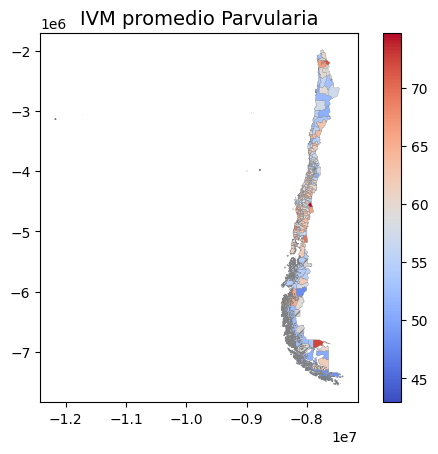

In [54]:
col = "IVM_Prom_Parvularia"

plt.figure(figsize=(8, 8))
base = gdf.copy()

base.plot(
    column=col,
    cmap="coolwarm",
    linewidth=0.2,
    edgecolor="gray",
    legend=True,
    missing_kwds={
        "color": "lightgray",
        "edgecolor": "gray",
        "hatch": "///",
        "label": "Sin datos"
    }
)

plt.title(f"IVM promedio Parvularia", fontsize=14)
plt.show()

<Figure size 800x800 with 0 Axes>

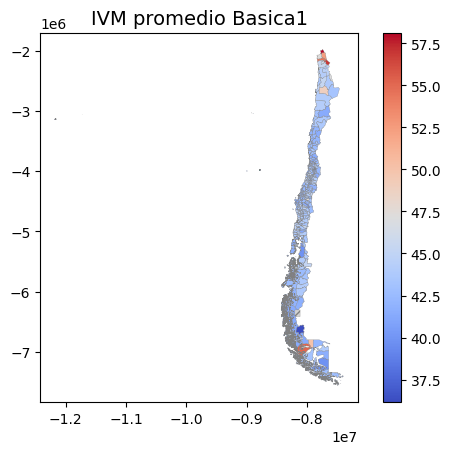

In [55]:
col = "IVM_Prom_Basica1"

plt.figure(figsize=(8, 8))
base = gdf.copy()

base.plot(
    column=col,
    cmap="coolwarm",
    linewidth=0.2,
    edgecolor="gray",
    legend=True,
    missing_kwds={
        "color": "lightgray",
        "edgecolor": "gray",
        "hatch": "///",
        "label": "Sin datos"
    }
)

plt.title(f"IVM promedio Basica1", fontsize=14)
plt.show()

<Figure size 800x800 with 0 Axes>

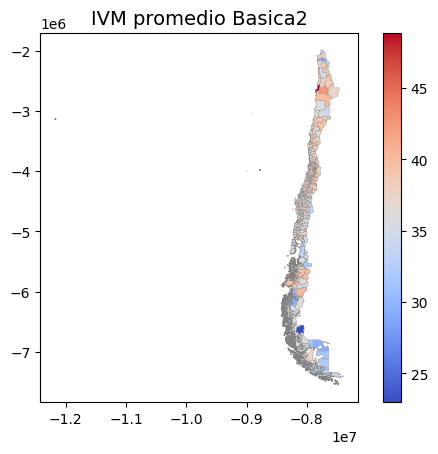

In [56]:
col = "IVM_Prom_Basica2"

plt.figure(figsize=(8, 8))
base = gdf.copy()

base.plot(
    column=col,
    cmap="coolwarm",
    linewidth=0.2,
    edgecolor="gray",
    legend=True,
    missing_kwds={
        "color": "lightgray",
        "edgecolor": "gray",
        "hatch": "///",
        "label": "Sin datos"
    }
)

plt.title(f"IVM promedio Basica2", fontsize=14)
plt.show()

<Figure size 800x800 with 0 Axes>

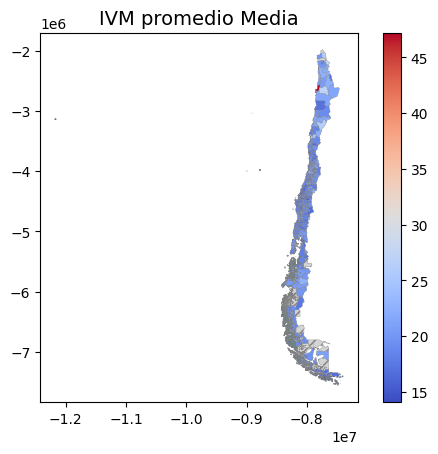

In [57]:
col = "IVM_Prom_Media"

plt.figure(figsize=(8, 8))
base = gdf.copy()

base.plot(
    column=col,
    cmap="coolwarm",
    linewidth=0.2,
    edgecolor="gray",
    legend=True,
    missing_kwds={
        "color": "lightgray",
        "edgecolor": "gray",
        "hatch": "///",
        "label": "Sin datos"
    }
)

plt.title(f"IVM promedio Media", fontsize=14)
plt.show()

**Respuesta**

La vulnerabilidad educativa en Chile disminuye dependiendo del nivel de enseñanza, pasando de alta en Parvularia a mas baja en Enseñanza Media.

En cuanto al territorio, las comunas rurales y del extremo norte y sur presentan los mayores niveles de vulnerabilidad, mientras que las zonas urbanas centrales tienen menores valores de IVM.

### 6.2 Relación entre ruralidad comunal y vulnerabilidad (0.7 pts)

En la sección **5.2** definimos el **porcentaje de ruralidad** de cada comuna según la cantidad de establecimientos rurales en cada una. Analice y visualice los datos en `agg_comunal` para responder la siguiente pregunta:

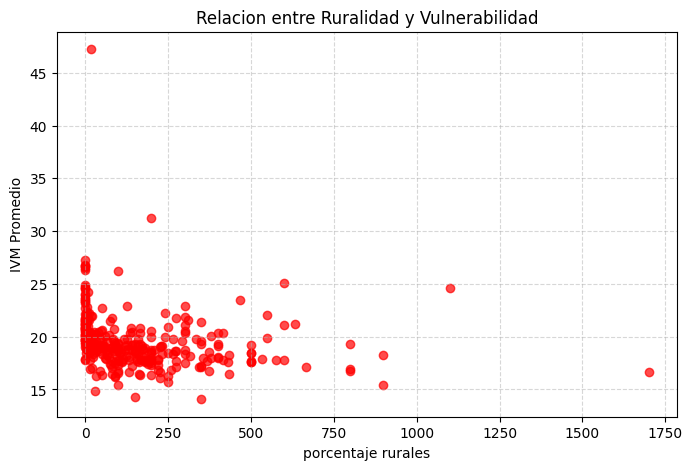

In [176]:
plt.figure(figsize=(8, 5))
plt.scatter(
    agg_comunal["porcentaje rurales"],
    agg_comunal["IVM Promedio Media de la comuna"],
    alpha=0.7,
    color="red"
)
plt.title("Relacion entre Ruralidad y Vulnerabilidad")
plt.xlabel("porcentaje rurales")
plt.ylabel("IVM Promedio")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

**¿Hay alguna correlación entre el IVM promedio y el porcentaje de ruralidad en las comunas de Chile?**

- Las comunas más rurales presentan mayor vulnerabilidad educativa, probablemente por:

    - menores recursos e infraestructura escolar,

    - mayor dispersión geográfica,

    - menor acceso a programas de apoyo.

- Sin embargo, la correlación no es fuerte, lo que indica que la ruralidad no explica por sí sola la vulnerabilidad: influyen también otros factores como la dependencia administrativa, nivel socioeconómico y acceso a servicios.

Al analizar el porcentaje de ruralidad y el IVM promedio por comuna, se observa una correlación positiva moderada (ρ ≈ 0.3). 
Esto sugiere que las comunas con mayor proporción de establecimientos rurales tienden a presentar una mayor vulnerabilidad promedio, 
aunque la relación no es determinante. Factores sociales y estructurales adicionales también influyen en los niveles de vulnerabilidad.

## 7 Pregunta Bono (2 punto)

* Proponga una pregunta de análisis que le interese responder con los datos de cualquiera de las bases de datos leídas o generadas durante esta Tarea.
Respóndala de la misma forma que las preguntas anteriores, generando una o varias visualizaciones y analizando sus resultados. Justifique 

**Recomendación**: Trate de proponer una pregunta que justifique el uso de agregación de datos y visualización. En otras palabras, que
no pueda ser respondida directamente sin el uso de gráficos (por ejemplo, *"¿cuál es el establecimiento con mayor IVM?"* puede ser respondida con una búsqueda rápida en el DataFrame).

**Pregunta propuesta:**

En que regiones hay mayor IVM educativa?

In [190]:
ivm_desv_region = ( # Agrupamos en cada region las comunas correspondientes 
    agg_comunal.groupby("Región (ID)")[[
        "IVM Promedio Parvularia de la comuna",
        "IVM Promedio Ciclo1 de la comuna",
        "IVM Promedio Ciclo2 de la comuna",
        "IVM Promedio Media de la comuna"
    ]].std() # Calcula la desviacion estandar #### LINEA HECHA CON IA ####
)

ivm_desv_region


,IVM Promedio Parvularia de la comuna,IVM Promedio Ciclo1 de la comuna,IVM Promedio Ciclo2 de la comuna,IVM Promedio Media de la comuna
Región (ID),,,,
1,7.525690,4.443579,2.949598,3.058857
2,3.035608,1.884524,3.968942,9.281030
3,4.533395,0.919571,1.554401,2.740218
4,4.349273,0.803939,1.701550,1.978542
5,2.289632,1.168132,1.153011,1.276662
6,3.585631,1.181790,1.325789,2.473900
7,3.164159,1.047148,1.358275,1.638842
8,5.033650,1.355156,1.585542,1.366711
9,3.977721,0.818625,1.642498,1.537736


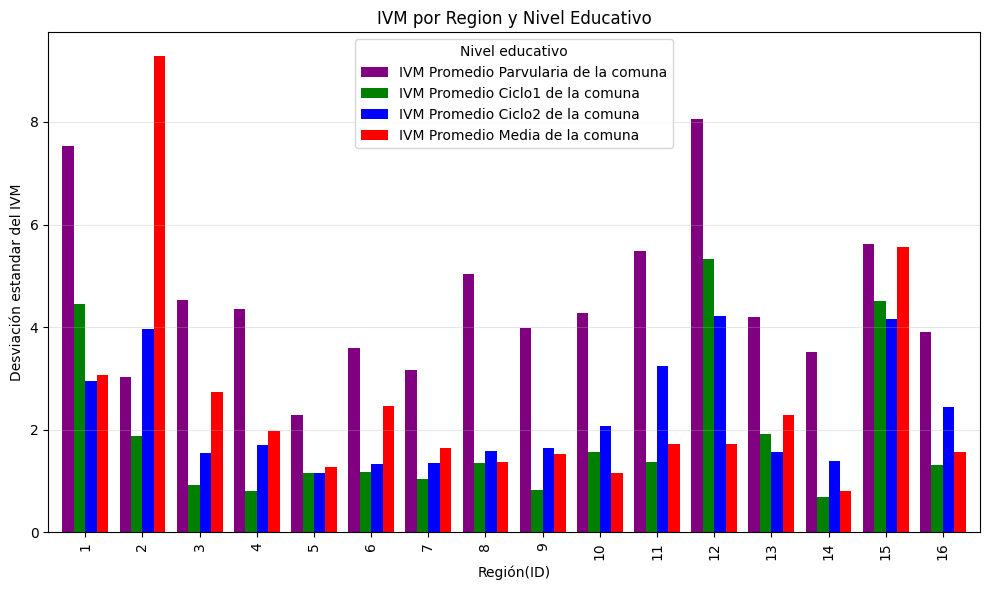

In [200]:
ivm_desv_region.plot(
    kind="bar",
    figsize=(10,6),
    width=0.8,
    color= ["purple", "green", "blue", "red"]
)

plt.title("IVM por Region y Nivel Educativo")
plt.xlabel("Región(ID)")
plt.ylabel("Desviación estandar del IVM")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Nivel educativo")
plt.tight_layout()
plt.show()

El grafico muestra que la desigualdad interna del IVM cambia entre regiones

- Las regiones 1 (Tarapaca), 2 (Antofagasta) y 12 (Magallanes) presentan mayor dispersión, visualizando diferencias entre comunas en vulnerabilidad educativa
Por otro lado, regiones como la 4 (Coquimbo) y 9 (La Araucanía) tienen niveles más similares

- Parvularia y Media muestran una diferencia notoria, mostrando que hay una gran diferencia entre estos dos sistemas educativos

La desigualdad educativa en Chile se ve reflejada tanto entre regiones como dentro de ellas